# Introduction

This project explores the factors that influence user clicks on YouTube videos.
The main focus is to analyze Click-Through Rate (CTR) and understand how
video performance metrics such as impressions, watch time, and engagement
affect user behavior.

The project combines statistical analysis, clustering techniques,
and machine learning models to predict video engagement and identify
patterns in user interaction.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from scipy.stats import ttest_ind

In [8]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [9]:
import zipfile
import os

zip_file = "archive.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall()

print("Files extracted:")
print(os.listdir())

Files extracted:
['.config', 'YouTube_Video.csv', 'archive (3) (1).zip', 'archive.zip', 'archive (3).zip', 'sample_data']


In [13]:
df = pd.read_csv("YouTube_Video.csv")

df.head()

,post_id,upload_date,video_duration_min,avg_view_duration_sec,avg_view_percentage,subscribers_gained,traffic_source,ctr_percentage,impressions,likes,comments,shares,total_watch_time_hours,content_category
0,YT0000001,2025-04-08 08:32:24.541512,45.55,2422,88.62,564,Shorts Feed,28.70,1975899,88186,1055,63,1329340.94,Sports
1,YT0000002,2025-06-30 08:32:24.541512,59.12,562,15.84,523,Notifications,25.67,1552915,69884,5883,131,242427.29,Vlog
2,YT0000003,2025-06-26 08:32:24.541512,40.06,2369,98.56,628,External,10.13,90886,37931,3746,2555,59808.04,News
3,YT0000004,2025-03-04 08:32:24.541512,42.54,2097,82.16,239,External,25.00,999294,38861,1575,900,582088.76,Education
4,YT0000005,2025-10-25 08:32:24.541512,31.40,1424,75.58,138,Shorts Feed,23.49,1656171,57043,3150,1452,655107.64,Sports


In [16]:
df.columns


Index(['post_id', 'upload_date', 'video_duration_min', 'avg_view_duration_sec',
       'avg_view_percentage', 'subscribers_gained', 'traffic_source',
       'ctr_percentage', 'impressions', 'likes', 'comments', 'shares',
       'total_watch_time_hours', 'content_category'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   post_id                 29999 non-null  object 
 1   upload_date             29999 non-null  object 
 2   video_duration_min      29999 non-null  float64
 3   avg_view_duration_sec   29999 non-null  int64  
 4   avg_view_percentage     29999 non-null  float64
 5   subscribers_gained      29999 non-null  int64  
 6   traffic_source          29999 non-null  object 
 7   ctr_percentage          29999 non-null  float64
 8   impressions             29999 non-null  int64  
 9   likes                   29999 non-null  int64  
 10  comments                29999 non-null  int64  
 11  shares                  29999 non-null  int64  
 12  total_watch_time_hours  29999 non-null  float64
 13  content_category        29999 non-null  object 
dtypes: float64(4), int64(6), object(4)
mem

In [18]:
df.describe()

,video_duration_min,avg_view_duration_sec,avg_view_percentage,subscribers_gained,ctr_percentage,impressions,likes,comments,shares,total_watch_time_hours
count,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,2.999900e+04,29999.000000,29999.000000,29999.000000,2.999900e+04
mean,30.481357,918.484049,50.243980,352.227908,15.071528,1.005525e+06,50031.577686,4010.686956,1503.401347,2.564022e+05
std,17.083015,791.358713,28.645129,202.444530,8.654916,5.770686e+05,28824.914627,2310.431564,866.938084,2.947842e+05
min,1.000000,5.000000,0.150000,0.000000,0.100000,1.060000e+02,1.000000,0.000000,0.000000,5.330000e+00
25%,15.605000,263.000000,25.585000,177.000000,7.500000,5.105605e+05,24983.500000,2019.500000,751.000000,4.435740e+04
50%,30.210000,696.000000,50.170000,354.000000,15.080000,1.004931e+06,50104.000000,4013.000000,1509.000000,1.436324e+05
75%,45.290000,1397.000000,74.810000,527.000000,22.560000,1.503998e+06,74905.000000,6018.500000,2251.000000,3.655550e+05
max,60.000000,3571.000000,100.000000,700.000000,30.000000,1.999924e+06,99989.000000,8000.000000,3000.000000,1.895754e+06


DATA CLEANING

In [19]:
df.duplicated().sum()

np.int64(0)

In [21]:
#MISSING VALUES
df.isnull().sum()

,0
post_id,0
upload_date,0
video_duration_min,0
avg_view_duration_sec,0
avg_view_percentage,0
subscribers_gained,0
traffic_source,0
ctr_percentage,0
impressions,0
likes,0


In [22]:
df['upload_date'] = pd.to_datetime(df['upload_date'])

In [23]:
df.dtypes

,0
post_id,object
upload_date,datetime64[ns]
video_duration_min,float64
avg_view_duration_sec,int64
avg_view_percentage,float64
subscribers_gained,int64
traffic_source,object
ctr_percentage,float64
impressions,int64
likes,int64


In [24]:
df_clean = df.copy()

In [26]:
#Unique values
df_clean['traffic_source'].value_counts()

,count
traffic_source,
Channel Page,3792
Browse,3786
Shorts Feed,3758
External,3747
Suggested,3747
Playlist,3737
Search,3729
Notifications,3703


In [27]:
df_clean['content_category'].value_counts()

,count
content_category,
Sports,3380
Tech,3368
Education,3358
Music,3343
Gaming,3336
Vlog,3334
News,3299
Comedy,3291
Reacts,3290


Insight:

The dataset shows a balanced distribution across traffic sources,
which ensures that the analysis is not biased toward a single type
of user acquisition channel.

The dataset is well balanced across content categories, with a similar number of observations in each group. This ensures that no category dominates the analysis, reducing bias and allowing fair comparison of CTR performance across different types of content.

2. Data Inspection and Preprocessing

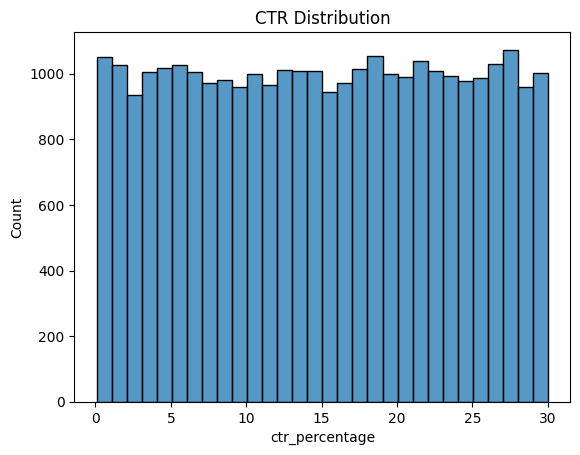

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['ctr_percentage'], bins=30)
plt.title("CTR Distribution")
plt.show()

In [30]:
df['ctr_percentage'].describe()

,ctr_percentage
count,29999.000000
mean,15.071528
std,8.654916
min,0.100000
25%,7.500000
50%,15.080000
75%,22.560000
max,30.000000


The CTR distribution shows a relatively balanced behavior with a mean and median around 15%, indicating a symmetric distribution. However, the standard deviation suggests high variability in video performance, meaning that some videos significantly outperform others in attracting clicks.

In [31]:
df[['ctr_percentage','impressions','likes','comments','shares']].corr()

,ctr_percentage,impressions,likes,comments,shares
ctr_percentage,1.000000,-0.003355,-0.000619,0.003349,0.013354
impressions,-0.003355,1.000000,0.003836,-0.007695,-0.012680
likes,-0.000619,0.003836,1.000000,0.003918,-0.010892
comments,0.003349,-0.007695,0.003918,1.000000,-0.000072
shares,0.013354,-0.012680,-0.010892,-0.000072,1.000000


The correlation analysis shows that CTR has almost no linear relationship with engagement metrics such as likes, comments, shares, or impressions. This suggests that click behavior is mostly influenced by pre-click factors such as video title, thumbnail, and recommendation placement rather than post-click engagement.

This notebook focused on data cleaning and initial exploration of YouTube CTR data.

Key findings:
- Dataset is clean with no missing values.
- CTR is normally distributed around 15%.
- No strong correlation between CTR and engagement metrics.
- Dataset is well balanced across categories and traffic sources.

This prepares the dataset for deeper exploratory analysis and modeling.

In [33]:
df.to_csv("youtube_cleaned.csv", index=False)